In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#from xgboost import XGBClassifier

In [4]:
df = pd.read_excel("../data/dataset1.xlsx")
df = df.drop(columns=['Timestamp'])
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (33, 16)
  Age group  Gender Highest education qualification     Employment  \
0   18 - 24    Male                  Advanced level       Employed   
1   25 - 34  Female               Bachelor's degree       Employed   
2   45 - 60    Male                 Master's degree       Employed   
3   45 - 60  Female                         Diploma  Self-employed   
4   45 - 60  Female                         Diploma       Employed   

     Job level Do you have a history of mental health issues?  \
0  Entry level                                             No   
1    Mid level                                   I don't know   
2       Senior                                             No   
3          NaN                                             No   
4    Mid level                                             No   

  How many hours of sleep do you get on average?  My workload is stressful.  \
0                                          4 - 6                          5   
1     

In [5]:
#Data cleaning
df_clean = df.copy()
print("\nMissing Values:\n", df_clean.isnull().sum())
df_clean=df_clean.dropna()
print(df.head())
print(df_clean.head())


Missing Values:
 Age group                                                                                   0
Gender                                                                                      0
Highest education qualification                                                             1
Employment                                                                                  0
Job level                                                                                   3
Do you have a history of mental health issues?                                              0
How many hours of sleep do you get on average?                                              0
My workload is stressful.                                                                   0
I am satisfied with my work-life balance.                                                   0
I feel secure in my job.                                                                    1
I can freely discuss my mental health at w

In [6]:
df_clean.columns

Index(['Age group', 'Gender', 'Highest education qualification', 'Employment',
       'Job level', 'Do you have a history of mental health issues?',
       'How many hours of sleep do you get on average?',
       'My workload is stressful.',
       'I am satisfied with my work-life balance.', 'I feel secure in my job.',
       'I can freely discuss my mental health at work',
       'I have less energy than I used to.',
       'I do not enjoy my hobbies as much as I used to.',
       'I am experiencing changes in sleep pattern (difficulty falling asleep/sleeping too much)',
       'I am experiencing changes in eating habits (overeating/loss of appetite)',
       'I struggle to relax in my time off work.'],
      dtype='object')

In [7]:
# The responses given to the above statements are as follows

#1 = Strongly disagree
#2 = Disagree
#3 = Neutral
#4 = Agree
#5 = Strongly Agree

# the responses need to be normalized so that more advserse risk factors are assigned a higher score.

In [8]:
#renaming columns for convenience and as a descriptor to scores

df_clean = df_clean.rename(columns={'Do you have a history of mental health issues?': 'history',
               'How many hours of sleep do you get on average?': 'low_sleep_time',
               'My workload is stressful.': 'work_stress',
               'I am satisfied with my work-life balance.': 'bad_work_life_balance',
               'I feel secure in my job.': 'low_security',
               'I can freely discuss my mental health at work': 'low_acceptance',
               'I have less energy than I used to.': 'low_energy',
               'I do not enjoy my hobbies as much as I used to.': 'low_joy',
               'I am experiencing changes in sleep pattern (difficulty falling asleep/sleeping too much)': 'low_sleep_quality',
               'I am experiencing changes in eating habits (overeating/loss of appetite)': 'low_appetite',
               'I struggle to relax in my time off work.': 'low_relaxation'})

df_clean.head()


,Age group,Gender,Highest education qualification,Employment,Job level,history,low_sleep_time,work_stress,bad_work_life_balance,low_security,low_acceptance,low_energy,low_joy,low_sleep_quality,low_appetite,low_relaxation
0,18 - 24,Male,Advanced level,Employed,Entry level,No,4 - 6,5,2,4.0,2.0,4,2,2,3,1
1,25 - 34,Female,Bachelor's degree,Employed,Mid level,I don't know,4 - 6,2,5,1.0,2.0,4,4,5,5,4
2,45 - 60,Male,Master's degree,Employed,Senior,No,4 - 6,3,2,2.0,1.0,4,4,5,3,3
4,45 - 60,Female,Diploma,Employed,Mid level,No,6 - 8,5,4,4.0,2.0,2,2,2,2,4
7,45 - 60,Male,Bachelor's degree,Employed,Senior,I don't know,6 - 8,4,2,2.0,1.0,4,3,5,2,4


In [9]:
#mapping history of mental illness to a score

mapping_history = {
    "I don't know": 2,
    "No": 1,
    "Yes, I have had treatment": 3,
    "Yes, I have not had treatment": 4
}

df_clean['history'] = df_clean['history'].map(mapping_history)

#mapping sleeping time to score indicating lower sleep time

mapping_sleep = {
    "Less than 4": 5,
    "4 - 6": 4,
    "6 - 8": 3,
    "8+": 1
}

df_clean['low_sleep_time'] = df_clean['low_sleep_time'].map(mapping_sleep)
print(df_clean.head())

  Age group  Gender Highest education qualification Employment    Job level  \
0   18 - 24    Male                  Advanced level   Employed  Entry level   
1   25 - 34  Female               Bachelor's degree   Employed    Mid level   
2   45 - 60    Male                 Master's degree   Employed       Senior   
4   45 - 60  Female                         Diploma   Employed    Mid level   
7   45 - 60    Male               Bachelor's degree   Employed       Senior   

   history  low_sleep_time  work_stress  bad_work_life_balance  low_security  \
0        1               4            5                      2           4.0   
1        2               4            2                      5           1.0   
2        1               4            3                      2           2.0   
4        1               3            5                      4           4.0   
7        2               3            4                      2           2.0   

   low_acceptance  low_energy  low_joy  low_

In [10]:
set(df_clean['history']) - set(mapping_history.keys())

{1, 2, 3, 4}

In [11]:
#inverting score to indicate proportional relationship to mental health risk

df_clean['bad_work_life_balance'] = (6 - df_clean['bad_work_life_balance']).astype(int)
df_clean['low_security'] = (6 - df_clean['low_security']).astype(int)
df_clean['low_acceptance'] = (6 - df_clean['low_acceptance']).astype(int)

In [12]:
print(df.head())
print(df_clean.head())

  Age group  Gender Highest education qualification     Employment  \
0   18 - 24    Male                  Advanced level       Employed   
1   25 - 34  Female               Bachelor's degree       Employed   
2   45 - 60    Male                 Master's degree       Employed   
3   45 - 60  Female                         Diploma  Self-employed   
4   45 - 60  Female                         Diploma       Employed   

     Job level Do you have a history of mental health issues?  \
0  Entry level                                             No   
1    Mid level                                   I don't know   
2       Senior                                             No   
3          NaN                                             No   
4    Mid level                                             No   

  How many hours of sleep do you get on average?  My workload is stressful.  \
0                                          4 - 6                          5   
1                             

In [13]:
#Creating overall mental health risk score
df_clean['mental_health_risk'] = (
    df_clean['bad_work_life_balance'] +
    df_clean['low_security'] +
    df_clean['low_acceptance'] +
    df_clean['low_energy'] +
    df_clean['low_joy'] +
    df_clean['low_sleep_quality'] +
    df_clean['low_appetite'] +
    df_clean['low_relaxation']
)

#Converting to categories
df_clean['mental_health_risk'] = pd.cut(
    df_clean['mental_health_risk'],
    bins=3,
    labels=[0, 1, 2]  # Low, Medium, High
)
print(df_clean.head())

  Age group  Gender Highest education qualification Employment    Job level  \
0   18 - 24    Male                  Advanced level   Employed  Entry level   
1   25 - 34  Female               Bachelor's degree   Employed    Mid level   
2   45 - 60    Male                 Master's degree   Employed       Senior   
4   45 - 60  Female                         Diploma   Employed    Mid level   
7   45 - 60    Male               Bachelor's degree   Employed       Senior   

   history  low_sleep_time  work_stress  bad_work_life_balance  low_security  \
0        1               4            5                      4             2   
1        2               4            2                      1             5   
2        1               4            3                      4             4   
4        1               3            5                      2             2   
7        2               3            4                      4             4   

   low_acceptance  low_energy  low_joy  low_

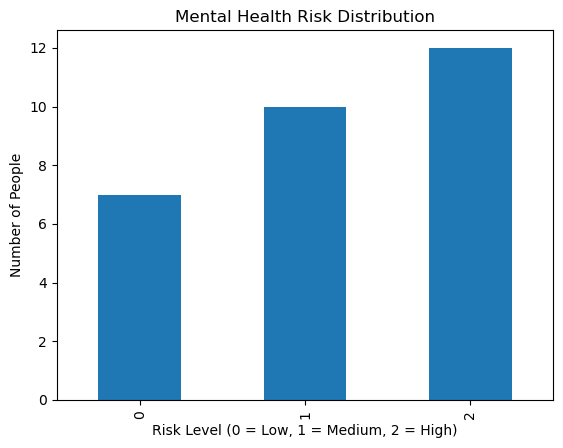

In [14]:
df_clean['mental_health_risk'].value_counts().sort_index().plot(kind='bar')

plt.title("Mental Health Risk Distribution")
plt.xlabel("Risk Level (0 = Low, 1 = Medium, 2 = High)")
plt.ylabel("Number of People")

plt.show()

In [15]:
#effect of risk factors only
target = 'mental_health_risk'

#Features
X = df_clean.drop(columns=[target,'Age group','Gender','Highest education qualification','Employment','Job level'])
y = df_clean[target]


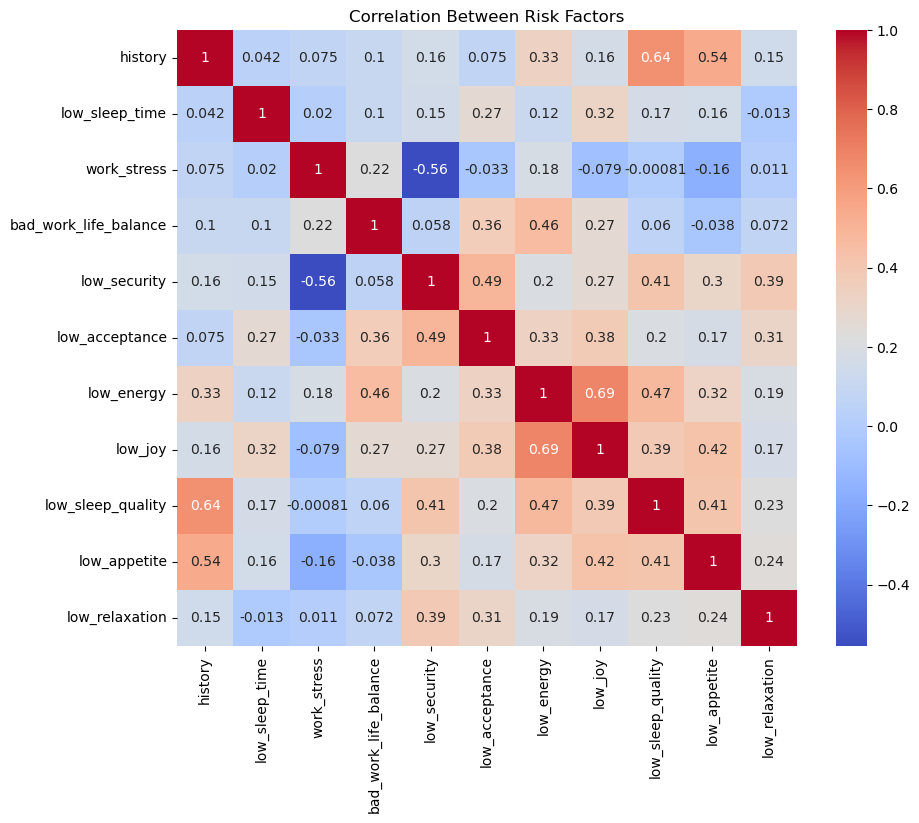

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df_clean.drop(columns=[target,'Age group','Gender','Highest education qualification','Employment','Job level']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Risk Factors")
plt.show()

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
print(y.value_counts(normalize=True))

mental_health_risk
2    0.413793
1    0.344828
0    0.241379
Name: proportion, dtype: float64


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [20]:
y_pred = lr_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.33      0.50      0.40         2
           2       0.50      0.33      0.40         3

    accuracy                           0.50         6
   macro avg       0.61      0.61      0.60         6
weighted avg       0.53      0.50      0.50         6



In [21]:
y_pred = cross_val_predict(lr_model, X, y, cv=5)

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.60      0.60      0.60        10
           2       0.75      0.75      0.75        12

    accuracy                           0.72        29
   macro avg       0.74      0.74      0.74        29
weighted avg       0.72      0.72      0.72        29



In [22]:
print(confusion_matrix(y, y_pred))


[[6 1 0]
 [1 6 3]
 [0 3 9]]


In [23]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

NameError: name 'XGBClassifier' is not defined